**Executive Summary:**

**Business Problem:** Evaluate demand forecast accuracy and identify inventory risks affecting retail operations.

**Approach:** Analyzed 73,100 sales and inventory records using Python and statistical analysis. Evaluated forecast accuracy using MAPE and MAE, performed bias analysis across stores, products, promotions, seasonality, and time periods, and applied a bias-correction approach.

**Key Finding:** The original forecast showed a persistent systematic over-forecasting bias of approximately **5 units per period.**

**Impact:** Bias correction improved MAPE from **24.72% to 22.13%**, representing a **10.51%** improvement, while MAE decreased from **8.34 to 7.50 units.**

**Business Value:** The analysis provides actionable insights for improving forecast calibration, prioritizing inventory replenishment, reducing potential overstock, and identifying no-sales inventory for review.

In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/retail_store_inventory.csv')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 73100
Columns: 15


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [41]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.describe(include="all")

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
count,73100,73100,73100,73100,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100,73100.000000,73100.000000,73100
unique,731,5,20,5,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4
top,2024-01-01,S001,P0001,Furniture,East,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,Spring
freq,100,14620,3655,14699,18349,NaN,NaN,NaN,NaN,NaN,NaN,18290,NaN,NaN,18317
mean,NaN,NaN,NaN,NaN,NaN,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,NaN,0.497305,55.146077,NaN
std,NaN,NaN,NaN,NaN,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,NaN,0.499996,26.191408,NaN
min,NaN,NaN,NaN,NaN,NaN,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,NaN,0.000000,5.030000,NaN
25%,NaN,NaN,NaN,NaN,NaN,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,NaN,0.000000,32.680000,NaN
50%,NaN,NaN,NaN,NaN,NaN,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,NaN,0.000000,55.010000,NaN
75%,NaN,NaN,NaN,NaN,NaN,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,NaN,1.000000,77.820000,NaN


In [44]:
# Actual demand vs Forecasted demand
df["Forecast Error"] = df["Units Sold"] - df["Demand Forecast"]
df["Absolute Forecast Error"] = abs(df["Forecast Error"])
df[[
    "Units Sold",
    "Demand Forecast",
    "Forecast Error",
    "Absolute Forecast Error"
]].head(10)

,Units Sold,Demand Forecast,Forecast Error,Absolute Forecast Error
0,127,135.47,-8.47,8.47
1,150,144.04,5.96,5.96
2,65,74.02,-9.02,9.02
3,61,62.18,-1.18,1.18
4,14,9.26,4.74,4.74
5,128,139.82,-11.82,11.82
6,97,108.92,-11.92,11.92
7,312,329.73,-17.73,17.73
8,175,174.15,0.85,0.85
9,28,24.47,3.53,3.53


In [45]:
# Mean Absolute Percentage Error
# This is first KPI(Overall Demand Forecast Error)
df["Absolute Percentage Error"] = (
    df["Absolute Forecast Error"] /
    df["Units Sold"].replace(0, np.nan)
) * 100
mape = df["Absolute Percentage Error"].mean()

print("MAPE:", round(mape, 2), "%")

MAPE: 24.72 %


In [46]:
# Forecast accuracy by Store
# Which stores have the highest forecast error?
store_mape = (
    df.groupby("Store ID")["Absolute Percentage Error"]
    .mean()
    .sort_values(ascending=False)
)

store_mape

,Absolute Percentage Error
Store ID,
S002,25.748967
S004,25.047589
S001,24.673731
S005,24.327567
S003,23.819650


In [47]:
# Forecast accuracy by Product
# Are certain products causing much higher forecast errors?
product_mape = (
    df.groupby("Product ID")["Absolute Percentage Error"]
    .mean()
    .sort_values(ascending=False)
)

product_mape

,Absolute Percentage Error
Product ID,
P0008,27.493141
P0015,26.983425
P0003,26.879706
P0012,26.244715
P0010,25.799642
P0001,25.713601
P0020,25.651023
P0002,25.379253
P0004,25.241452


In [48]:
# Analyze P0008
# Does P0008 genuinely have large forecasting errors or is its MAPE high mainly because its sales volume is lower?
product_summary = df.groupby("Product ID").agg(
    Avg_Units_Sold=("Units Sold", "mean"),
    Avg_Demand_Forecast=("Demand Forecast", "mean"),
    Avg_Absolute_Error=("Absolute Forecast Error", "mean"),
    MAPE=("Absolute Percentage Error", "mean")
).sort_values("MAPE", ascending=False)

product_summary

,Avg_Units_Sold,Avg_Demand_Forecast,Avg_Absolute_Error,MAPE
Product ID,,,,
P0008,133.669767,138.670397,8.274495,27.493141
P0015,138.791518,143.911885,8.274676,26.983425
P0003,134.960055,140.131806,8.467089,26.879706
P0012,134.519836,139.560027,8.380328,26.244715
P0010,135.832832,140.654304,8.294347,25.799642
P0001,136.268399,141.428605,8.333212,25.713601
P0020,138.907798,143.662826,8.267932,25.651023
P0002,133.468399,138.496235,8.262222,25.379253
P0004,135.567989,140.719283,8.417111,25.241452


In [49]:
# Check forecast bias
# Does the forecast systematically overestimate or underestimate demand?
product_bias = (
    df.groupby("Product ID")["Forecast Error"]
    .mean()
    .sort_values()
)

product_bias

,Forecast Error
Product ID,
P0018,-5.285631
P0013,-5.211097
P0003,-5.171751
P0001,-5.160205
P0004,-5.151294
P0015,-5.120367
P0017,-5.074101
P0007,-5.050966
P0009,-5.046766


In [50]:
# Quantify the overall forecast bias
overall_bias = df["Forecast Error"].mean()

print("Overall Forecast Bias:", round(overall_bias, 2))
avg_units_sold = df["Units Sold"].mean()
avg_demand_forecast = df["Demand Forecast"].mean()

print("Average Units Sold:", round(avg_units_sold, 2))
print("Average Demand Forecast:", round(avg_demand_forecast, 2))

Overall Forecast Bias: -5.03
Average Units Sold: 136.46
Average Demand Forecast: 141.49


In [51]:
# Inventory analysis
# Is this over-forecasting associated with excess inventory or over-ordering?
inventory_summary = df[[
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast"
]].describe()

inventory_summary

,Inventory Level,Units Sold,Units Ordered,Demand Forecast
count,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720
std,129.949514,108.919406,52.277448,109.254076
min,50.000000,0.000000,20.000000,-9.990000
25%,162.000000,49.000000,65.000000,53.670000
50%,273.000000,107.000000,110.000000,113.015000
75%,387.000000,203.000000,155.000000,208.052500
max,500.000000,499.000000,200.000000,518.550000


In [52]:
# Analyze the ordering gap
df["Order Gap vs Sales"] = df["Units Ordered"] - df["Units Sold"]
df["Order Gap vs Forecast"] = (
    df["Units Ordered"] - df["Demand Forecast"]
)
print("Average Order Gap vs Sales:",
      round(df["Order Gap vs Sales"].mean(), 2))

print("Average Order Gap vs Forecast:",
      round(df["Order Gap vs Forecast"].mean(), 2))

Average Order Gap vs Sales: -26.46
Average Order Gap vs Forecast: -31.49


In [53]:
# Create Inventory Coverage
df["Inventory Coverage"] = (
    df["Inventory Level"] /
    df["Units Sold"].replace(0, np.nan)
)
df[[
    "Inventory Level",
    "Units Sold",
    "Inventory Coverage"
]].head(10)

,Inventory Level,Units Sold,Inventory Coverage
0,231,127,1.818898
1,204,150,1.360000
2,102,65,1.569231
3,469,61,7.688525
4,166,14,11.857143
5,138,128,1.078125
6,359,97,3.701031
7,380,312,1.217949
8,183,175,1.045714
9,108,28,3.857143


In [54]:
# Summary of Inventory Coverage
df["Inventory Coverage"].describe()

,Inventory Coverage
count,72740.000000
mean,6.165394
std,21.061941
min,1.000000
25%,1.333333
50%,2.007407
75%,4.000000
max,493.000000


In [55]:
# Create Inventory Risk Classification
def classify_inventory(coverage):
    if pd.isna(coverage):
        return "No Sales / Review"
    elif coverage <= 1.33:
        return "Low Coverage"
    elif coverage <= 4:
        return "Adequate Coverage"
    else:
        return "High Coverage"


df["Inventory Risk"] = df["Inventory Coverage"].apply(classify_inventory)
df["Inventory Risk"].value_counts()

,count
Inventory Risk,
Adequate Coverage,36582
High Coverage,18116
Low Coverage,18042
No Sales / Review,360


In [56]:
# Find where the risks occur
# Which stores have the highest proportion of Low Coverage and High Coverage?
# Analyze by Store
store_inventory_risk = pd.crosstab(
    df["Store ID"],
    df["Inventory Risk"],
    normalize="index"
) * 100

store_inventory_risk.round(2)

Inventory Risk,Adequate Coverage,High Coverage,Low Coverage,No Sales / Review
Store ID,,,,
S001,49.47,25.35,24.60,0.57
S002,50.56,24.80,24.21,0.43
S003,50.19,24.42,24.87,0.52
S004,49.93,24.58,24.99,0.51
S005,50.06,24.77,24.74,0.43


In [57]:
# Analyze by Product
# Are particular products more likely to have Low Coverage or High Coverage?
product_inventory_risk = pd.crosstab(
    df["Product ID"],
    df["Inventory Risk"],
    normalize="index"
) * 100

product_inventory_risk.round(2)

Inventory Risk,Adequate Coverage,High Coverage,Low Coverage,No Sales / Review
Product ID,,,,
P0001,49.82,25.28,24.40,0.49
P0002,50.70,24.95,23.94,0.41
P0003,49.33,26.05,24.27,0.36
P0004,48.84,24.87,25.64,0.66
P0005,52.20,22.98,24.49,0.33
P0006,50.86,24.46,24.24,0.44
P0007,49.99,24.76,24.71,0.55
P0008,48.81,26.54,24.21,0.44
P0009,50.26,24.79,24.68,0.27


In [58]:
# Analyze Promotions
# whether forecast accuracy changes during promotions?
promotion_analysis = df.groupby("Holiday/Promotion").agg(
    Avg_Units_Sold=("Units Sold", "mean"),
    Avg_Demand_Forecast=("Demand Forecast", "mean"),
    Avg_Forecast_Error=("Forecast Error", "mean"),
    MAPE=("Absolute Percentage Error", "mean"),
    Avg_Inventory=("Inventory Level", "mean"),
    Avg_Units_Ordered=("Units Ordered", "mean")
)

promotion_analysis.round(2)


,Avg_Units_Sold,Avg_Demand_Forecast,Avg_Forecast_Error,MAPE,Avg_Inventory,Avg_Units_Ordered
Holiday/Promotion,,,,,,
0,136.51,141.55,-5.05,25.15,274.03,109.72
1,136.42,141.44,-5.01,24.30,274.92,110.29


In [59]:
# Analyze Seasonality
season_analysis = df.groupby("Seasonality").agg(
    Avg_Units_Sold=("Units Sold", "mean"),
    Avg_Demand_Forecast=("Demand Forecast", "mean"),
    Avg_Forecast_Error=("Forecast Error", "mean"),
    MAPE=("Absolute Percentage Error", "mean"),
    Avg_Inventory=("Inventory Level", "mean"),
    Avg_Units_Ordered=("Units Ordered", "mean")
)

season_analysis.round(2)

,Avg_Units_Sold,Avg_Demand_Forecast,Avg_Forecast_Error,MAPE,Avg_Inventory,Avg_Units_Ordered
Seasonality,,,,,,
Autumn,137.78,142.80,-5.02,23.94,275.42,109.77
Spring,135.83,140.81,-4.99,26.26,274.74,109.75
Summer,135.43,140.47,-5.04,25.08,273.07,110.40
Winter,136.83,141.90,-5.07,23.61,274.65,110.10


In [60]:
# Competitor Pricing Analysis
df["Price Difference"] = df["Price"] - df["Competitor Pricing"]
df[[
    "Price",
    "Competitor Pricing",
    "Price Difference",
    "Units Sold",
    "Demand Forecast"
]].corr(numeric_only=True)

,Price,Competitor Pricing,Price Difference,Units Sold,Demand Forecast
Price,1.000000,0.993900,-0.003357,0.001082,0.000675
Competitor Pricing,0.993900,1.000000,-0.113621,0.001259,0.000844
Price Difference,-0.003357,-0.113621,1.000000,-0.001674,-0.001570
Units Sold,0.001082,0.001259,-0.001674,1.000000,0.996853
Demand Forecast,0.000675,0.000844,-0.001570,0.996853,1.000000


In [61]:
# Check the forecast bias over time
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
monthly_analysis = df.groupby("Month").agg(
    Avg_Units_Sold=("Units Sold", "mean"),
    Avg_Demand_Forecast=("Demand Forecast", "mean"),
    Avg_Forecast_Error=("Forecast Error", "mean"),
    MAPE=("Absolute Percentage Error", "mean")
)

monthly_analysis.round(2)

,Avg_Units_Sold,Avg_Demand_Forecast,Avg_Forecast_Error,MAPE
Month,,,,
2022-01,135.46,140.51,-5.05,23.81
2022-02,139.66,144.82,-5.16,25.01
2022-03,137.44,142.60,-5.16,22.95
2022-04,135.79,140.82,-5.02,25.06
2022-05,133.81,138.62,-4.82,24.45
2022-06,138.50,143.50,-4.99,25.82
2022-07,137.62,142.63,-5.01,23.08
2022-08,137.07,142.05,-4.98,24.50
2022-09,137.20,142.36,-5.15,25.22


In [62]:
# Bias-corrected forecast
# Average systematic bias
bias = df["Demand Forecast"].mean() - df["Units Sold"].mean()

print("Estimated Forecast Bias:", round(bias, 2))
df["Bias Corrected Forecast"] = df["Demand Forecast"] - bias
df["Corrected Forecast Error"] = (
    df["Units Sold"] - df["Bias Corrected Forecast"]
)

df["Corrected Absolute Error"] = (
    df["Corrected Forecast Error"].abs()
)
# compare the original and corrected forecasts
comparison = pd.DataFrame({
    "Original MAE": [df["Absolute Forecast Error"].mean()],
    "Corrected MAE": [df["Corrected Absolute Error"].mean()],
    "Original Bias": [df["Forecast Error"].mean()],
    "Corrected Bias": [df["Corrected Forecast Error"].mean()]
})

comparison.round(2)

Estimated Forecast Bias: 5.03


,Original MAE,Corrected MAE,Original Bias,Corrected Bias
0,8.34,7.5,-5.03,0.0


In [63]:
# Original MAPE vs Corrected MAPE
# Calculate corrected absolute percentage error
df["Corrected Absolute Percentage Error"] = (
    df["Corrected Absolute Error"] /
    df["Units Sold"].replace(0, np.nan)
) * 100

original_mape = df["Absolute Percentage Error"].mean()
corrected_mape = df["Corrected Absolute Percentage Error"].mean()

print("Original MAPE:", round(original_mape, 2), "%")
print("Corrected MAPE:", round(corrected_mape, 2), "%")

print(
    "MAPE Improvement:",
    round(
        ((original_mape - corrected_mape) / original_mape) * 100,
        2
    ),
    "%"
)

Original MAPE: 24.72 %
Corrected MAPE: 22.13 %
MAPE Improvement: 10.51 %


In [64]:
# Create monthly data
monthly_visual = df.groupby("Month").agg(
    Actual_Units_Sold=("Units Sold", "mean"),
    Original_Forecast=("Demand Forecast", "mean"),
    Corrected_Forecast=("Bias Corrected Forecast", "mean")
).reset_index()

# Convert Month to a readable datetime format
monthly_visual["Month"] = monthly_visual["Month"].astype(str)

monthly_visual.head()

,Month,Actual_Units_Sold,Original_Forecast,Corrected_Forecast
0,2022-01,135.463871,140.512813,135.482963
1,2022-02,139.661429,144.816579,139.786729
2,2022-03,137.442903,142.601745,137.571895
3,2022-04,135.793333,140.815277,135.785427
4,2022-05,133.806129,138.623329,133.593479


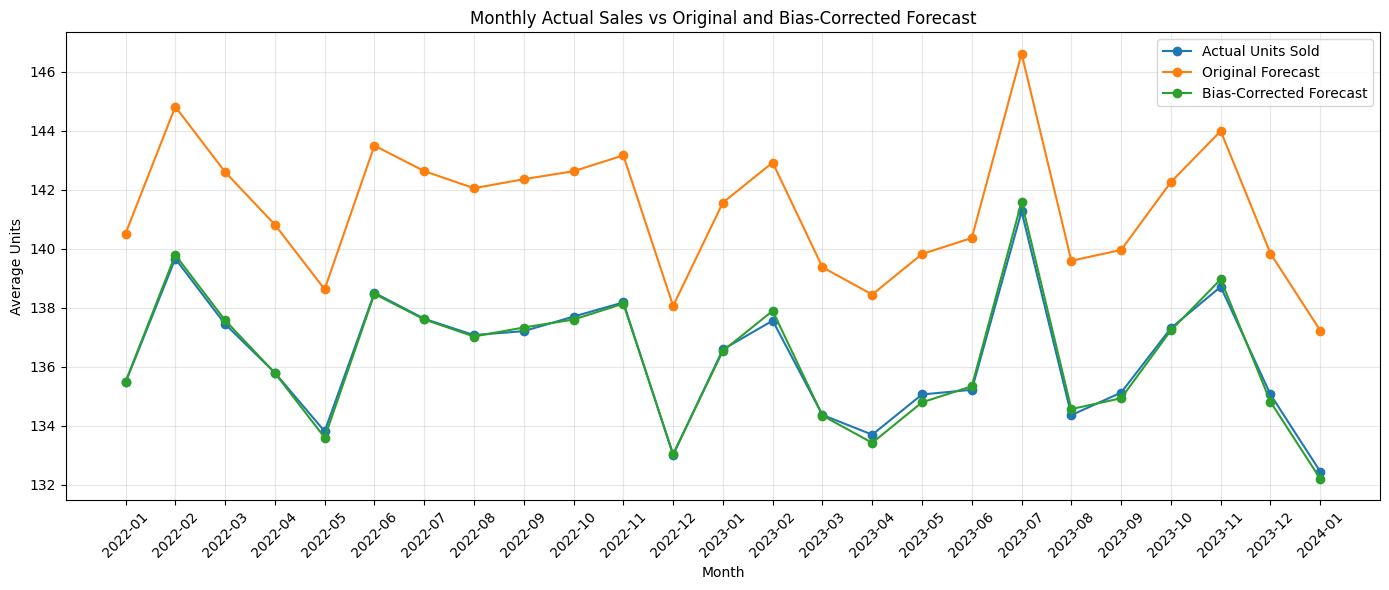

In [65]:
# Create the chart
# Actual Units Sold vs Original Forecast vs Bias-Corrected Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_visual["Month"],
    monthly_visual["Actual_Units_Sold"],
    marker="o",
    label="Actual Units Sold"
)

plt.plot(
    monthly_visual["Month"],
    monthly_visual["Original_Forecast"],
    marker="o",
    label="Original Forecast"
)

plt.plot(
    monthly_visual["Month"],
    monthly_visual["Corrected_Forecast"],
    marker="o",
    label="Bias-Corrected Forecast"
)

plt.title("Monthly Actual Sales vs Original and Bias-Corrected Forecast")
plt.xlabel("Month")
plt.ylabel("Average Units")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

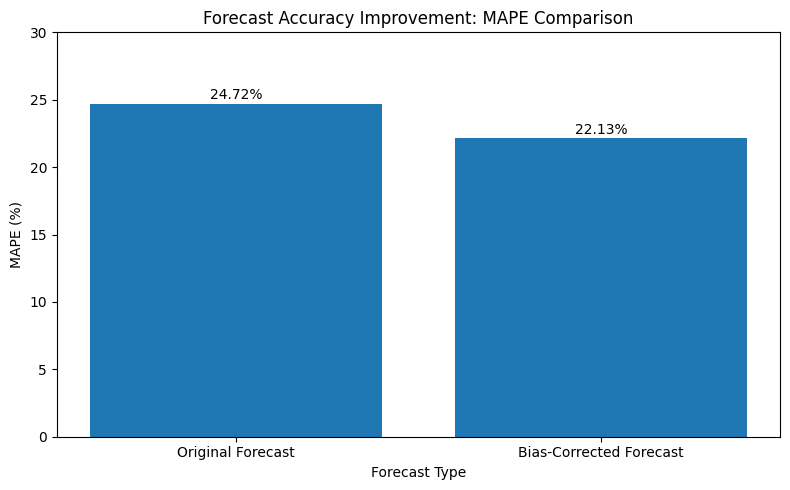

In [66]:
# Original MAPE vs Corrected MAPE(10.51% improvement)
import matplotlib.pyplot as plt

mape_values = [24.72, 22.13]
labels = ["Original Forecast", "Bias-Corrected Forecast"]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, mape_values)

plt.title("Forecast Accuracy Improvement: MAPE Comparison")
plt.xlabel("Forecast Type")
plt.ylabel("MAPE (%)")

# Add values on top of bars
for bar, value in zip(bars, mape_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 30)
plt.tight_layout()
plt.show()

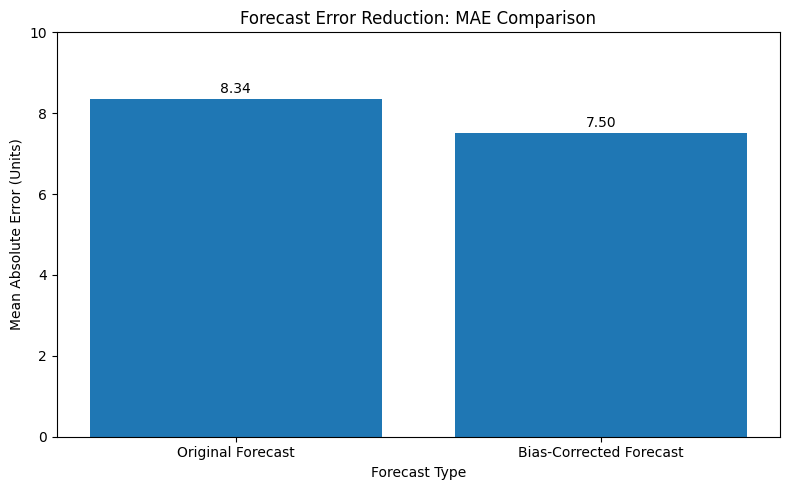

In [67]:
# Original MAE vs Corrected MAE(10.1% improvement)
import matplotlib.pyplot as plt

mae_values = [8.34, 7.50]
labels = ["Original Forecast", "Bias-Corrected Forecast"]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, mae_values)

plt.title("Forecast Error Reduction: MAE Comparison")
plt.xlabel("Forecast Type")
plt.ylabel("Mean Absolute Error (Units)")

# Add values on top of bars
for bar, value in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{value:.2f}",
        ha="center"
    )

plt.ylim(0, 10)
plt.tight_layout()
plt.show()

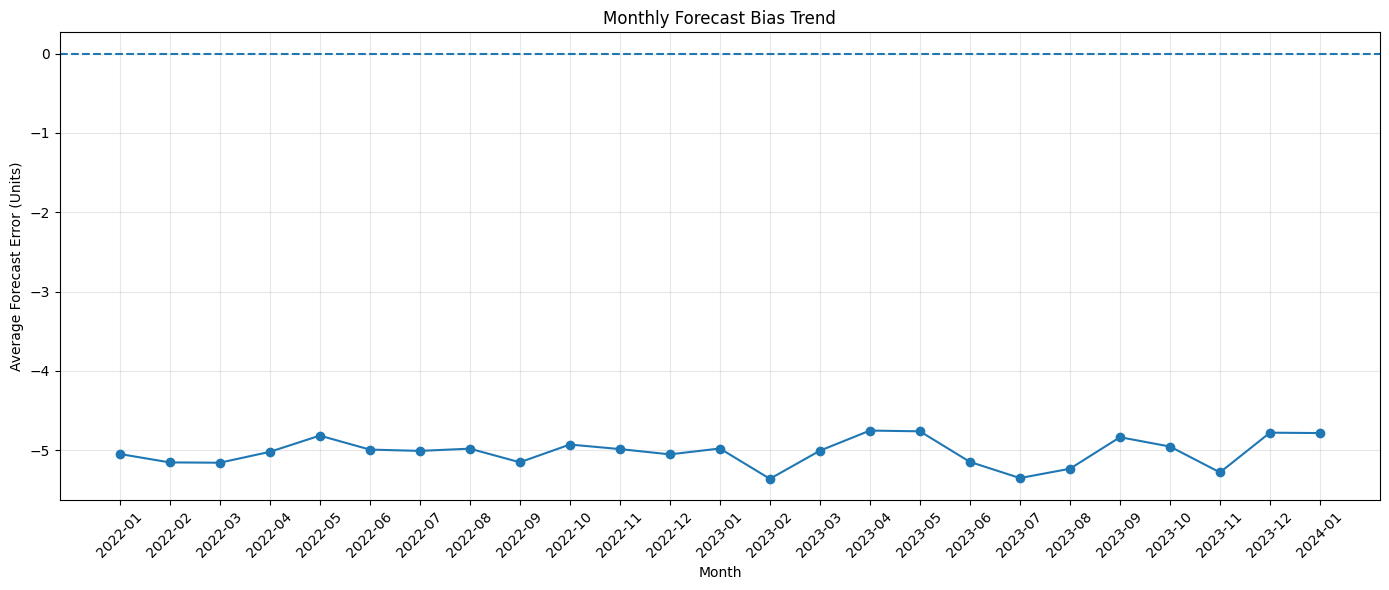

In [68]:
# Monthly Forecast Bias Trend
import matplotlib.pyplot as plt

# Use the monthly analysis we already created
monthly_bias = monthly_analysis.reset_index()

# Convert Month to string for plotting
monthly_bias["Month"] = monthly_bias["Month"].astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_bias["Month"],
    monthly_bias["Avg_Forecast_Error"],
    marker="o"
)

# Reference line for zero bias
plt.axhline(y=0, linestyle="--")

plt.title("Monthly Forecast Bias Trend")
plt.xlabel("Month")
plt.ylabel("Average Forecast Error (Units)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

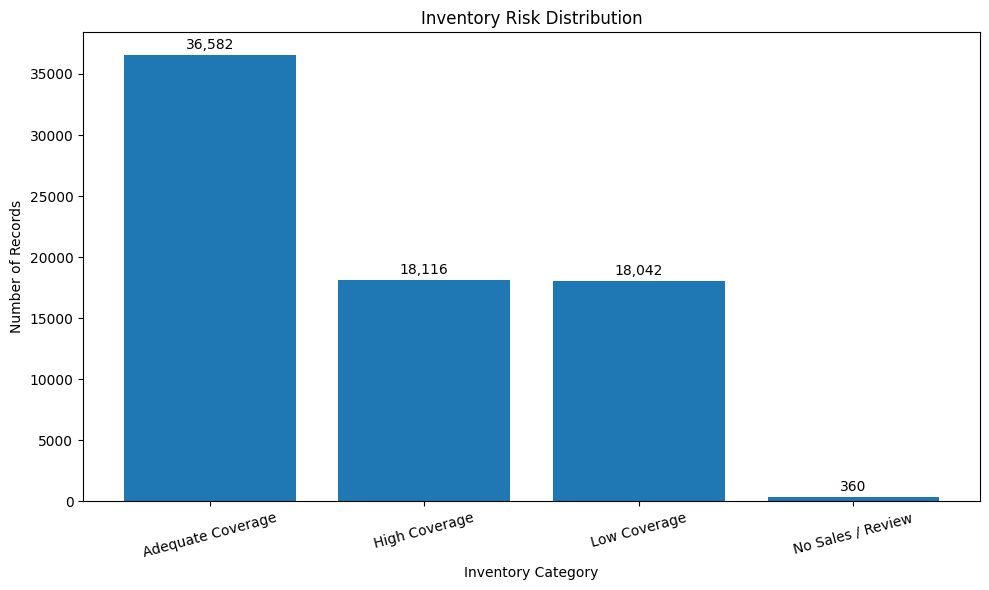

In [69]:
# Inventory Risk Distribution
import matplotlib.pyplot as plt

# Count inventory records in each risk category
risk_counts = df["Inventory Risk"].value_counts()

# Put categories in business-friendly order
category_order = [
    "Adequate Coverage",
    "High Coverage",
    "Low Coverage",
    "No Sales / Review"
]

risk_counts = risk_counts.reindex(category_order)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Inventory Risk Distribution")
plt.xlabel("Inventory Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=15)

# Add counts above bars
for bar, value in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

**Conclusion:**

This project analyzed **73,100 retail sales and inventory records** to evaluate demand forecast accuracy and identify opportunities for improving inventory decisions.

The analysis identified a persistent **systematic over-forecasting bias**. The original demand forecast was consistently higher than actual units sold, with an average forecast bias of approximately **-5.03 units.**

A bias-correction approach was applied to calibrate the forecasts. This improved forecast performance:

*   MAPE reduced from 24.72% to 22.13%
*   MAPE improved by 10.51%
*   MAE reduced from 8.34 to 7.50 units
*   Average forecast bias improved from -5.03 to approximately 0

The inventory analysis also showed that **36,582 records had adequate inventory coverage**, while approximately half of the records fell into either **high-coverage or low-coverage risk categories**, indicating opportunities to improve replenishment and inventory allocation.

Overall, the project demonstrates how data analysis can be used to identify forecasting issues, perform root-cause analysis, improve forecast accuracy, and translate analytical findings into actionable business recommendations.

**Business Recommendations:**
1. **Implement Forecast Bias Monitoring**

The persistent negative forecast error indicates systematic over-forecasting. Forecast performance should be monitored regularly using:

*   Forecast Bias
*   MAPE
*   MAE

A significant or persistent bias should trigger a review of the forecasting model or calibration process.

2. **Apply Forecast Calibration**

The bias-correction approach improved MAPE by **10.51%** and reduced MAE by approximately **10.1%**. A similar calibration step can be incorporated into the forecasting workflow to reduce systematic forecast errors.

3. **Prioritize Low-Coverage Inventory**

Records with low inventory coverage should be prioritized for replenishment to reduce the risk of stockouts and lost sales.

4. **Review High-Coverage Inventory**

High-coverage products or locations should be investigated for potential excess inventory. Possible actions include:

*  Reducing future replenishment quantities
*  Reallocating inventory to higher-demand locations
*  Reviewing demand assumptions

5. **Investigate No-Sales Inventory**

The **360 no-sales/review records** should be examined individually to identify possible inactive, slow-moving, obsolete, or incorrectly forecasted products.